# GNN Training for Network Anomaly Prediction

This notebook contains the complete pipeline for training Graph Neural Networks on network telemetry data to predict anomalies.

## Contents
1. [Setup & Dependencies](#setup)
2. [Dataset Loading](#dataset)
3. [Model Architecture](#model)
4. [Training](#training)
5. [Evaluation](#evaluation)
6. [Inference](#inference)
7. [Visualization](#viz)

In [65]:
import json
import os
import sys
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Optional, Tuple
import numpy as np
# Check if torch is available, if not install it
try:
    import torch
    print(f"Ã¢ÂÂ PyTorch {torch.__version__} already installed")
except ImportError:
    print("PyTorch not found. Installing...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "--index-url", "https://download.pytorch.org/whl/cpu", "--no-cache-dir", "--quiet"])
    import torch
    print(f"Ã¢ÂÂ PyTorch {torch.__version__} installed")
# Check torch_geometric
try:
    import torch_geometric
    print(f"Ã¢ÂÂ PyTorch Geometric {torch_geometric.__version__} already installed")
except ImportError:
    print("PyTorch Geometric not found. Installing...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch-geometric", "--no-cache-dir", "--quiet"])
    import torch_geometric
    print(f"Ã¢ÂÂ PyTorch Geometric {torch_geometric.__version__} installed")
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset
from torch_geometric.data import Batch, Data
from torch_geometric.nn import GATConv
from tqdm import tqdm
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
# Set random seeds
torch.manual_seed(42)
np.random.seed(42)
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Ã¢ÂÂ PyTorch 2.11.0 already installed
Ã¢ÂÂ PyTorch Geometric 2.7.0 already installed

Using device: cpu


In [66]:
import json
import os
import sys
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Optional, Tuple
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset
from torch_geometric.data import Batch, Data
from torch_geometric.nn import GATConv
from tqdm import tqdm
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
# Set random seeds
torch.manual_seed(42)
np.random.seed(42)
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


## 2. Dataset Loading <a name="dataset"></a>

Define the PyTorch Geometric dataset for loading JSON snapshots:

In [67]:
class NetworkGNNDataset(Dataset):
    """Dataset for network telemetry graph snapshots."""
    
    def __init__(
        self,
        data_dir: str,
        horizon: str = "horizon_30s",
        node_feature_dim: int = 14,
        edge_feature_dim: int = 6,
        seq_len: int = 5,
    ):
        self.data_dir = Path(data_dir)
        self.horizon = horizon
        self.node_feature_dim = node_feature_dim
        self.edge_feature_dim = edge_feature_dim
        self.seq_len = seq_len
        
        # Load metadata
        with open(self.data_dir / "metadata.json", "r") as f:
            self.metadata = json.load(f)
        
        self.num_nodes = len(self.metadata["node_names"])
        self.label_to_index = self.metadata["label_to_index"]
        self.index_to_label = {v: k for k, v in self.label_to_index.items()}
        self.num_classes = len(self.label_to_index)
        
        # Build edge index
        self.edge_index = self._build_edge_index()
        
        # Get snapshot files
        snap_dir = self.data_dir / "snapshots"
        self.snapshot_files = sorted(
            [f for f in snap_dir.glob("window_*.json")],
            key=lambda x: int(x.stem.split("_")[1])
        )
        
        if len(self.snapshot_files) < seq_len:
            raise ValueError(f"Need at least {seq_len} snapshots, got {len(self.snapshot_files)}")
        
        self.num_sequences = len(self.snapshot_files) - seq_len + 1
    
    def _build_edge_index(self) -> torch.Tensor:
        """Build edge index from topology."""
        edges = self.metadata.get("edges", [])
        node_index = self.metadata["node_index"]
        
        edge_pairs = []
        for src_name, dst_name in edges:
            if src_name in node_index and dst_name in node_index:
                edge_pairs.append([node_index[src_name], node_index[dst_name]])
                edge_pairs.append([node_index[dst_name], node_index[src_name]])
        
        if not edge_pairs:
            for i in range(self.num_nodes):
                for j in range(self.num_nodes):
                    if i != j:
                        edge_pairs.append([i, j])
        
        return torch.tensor(edge_pairs, dtype=torch.long).t().contiguous()
    
    def _load_snapshot(self, file_path: Path) -> Dict:
        with open(file_path, "r") as f:
            return json.load(f)
    
    def __len__(self) -> int:
        return self.num_sequences
    
    def __getitem__(self, idx: int) -> Data:
        # Load sequence
        seq_snapshots = []
        for i in range(self.seq_len):
            snap_file = self.snapshot_files[idx + i]
            seq_snapshots.append(self._load_snapshot(snap_file))
        
        # Build features
        node_features_seq = []
        for snap in seq_snapshots:
            node_feats = torch.tensor(snap["node_features"], dtype=torch.float)
            node_features_seq.append(node_feats)
        
        node_features = torch.stack(node_features_seq, dim=0)
        node_features = node_features.transpose(0, 1)  # [num_nodes, seq_len, features]
        
        last_snap = seq_snapshots[-1]
        edge_features = torch.tensor(last_snap.get("edge_features", []), dtype=torch.float)
        
        if edge_features.shape[0] == 0:
            num_edges = self.edge_index.shape[1]
            edge_features = torch.zeros(num_edges, self.edge_feature_dim)
        
        pred_labels = last_snap.get("prediction_labels", {}).get(self.horizon, {})
        
        node_label_indices = pred_labels.get("node_indices", [0] * self.num_nodes)
        y = torch.tensor(node_label_indices, dtype=torch.long)
        
        window_label_idx = pred_labels.get("window_index", 0)
        y_window = torch.tensor([window_label_idx], dtype=torch.long)
        
        current_labels = last_snap.get("current_labels", {})
        y_current = torch.tensor(
            current_labels.get("node_indices", [0] * self.num_nodes),
            dtype=torch.long
        )
        
        return Data(
            x=node_features,
            edge_index=self.edge_index,
            edge_attr=edge_features,
            y=y,
            y_window=y_window,
            y_current=y_current,
            window_idx=idx,
        )
    
    def split(self, train_ratio=0.7, val_ratio=0.15):
        """Split dataset."""
        total = len(self)
        train_size = int(total * train_ratio)
        val_size = int(total * val_ratio)
        
        indices = list(range(total))
        np.random.shuffle(indices)
        
        train_idx = indices[:train_size]
        val_idx = indices[train_size:train_size + val_size]
        test_idx = indices[train_size + val_size:]
        
        return (
            SubsetDataset(self, train_idx),
            SubsetDataset(self, val_idx),
            SubsetDataset(self, test_idx),
        )
class SubsetDataset(Dataset):
    """Subset wrapper."""
    def __init__(self, dataset: NetworkGNNDataset, indices: List[int]):
        self.dataset = dataset
        self.indices = indices
        self.num_classes = dataset.num_classes
        self.label_to_index = dataset.label_to_index
        self.index_to_label = dataset.index_to_label
        self.metadata = dataset.metadata
        self.num_nodes = dataset.num_nodes
    
    def __len__(self) -> int:
        return len(self.indices)
    
    def __getitem__(self, idx: int) -> Data:
        return self.dataset[self.indices[idx]]
def collate_fn(batch):
    """Collate function for batching."""
    return Batch.from_data_list(batch)
# Test dataset loading
DATA_DIR = "data/gnn_datasets/gnn_20260505_181430"
dataset = NetworkGNNDataset(DATA_DIR, horizon="horizon_30s", seq_len=5)
print(f"Dataset loaded: {len(dataset)} sequences")
print(f"Nodes: {dataset.num_nodes}, Classes: {dataset.num_classes}")
sample = dataset[0]
print(f"\nSample shape: x={sample.x.shape}, edge_index={sample.edge_index.shape}")


Dataset loaded: 1229 sequences
Nodes: 26, Classes: 21

Sample shape: x=torch.Size([26, 5, 14]), edge_index=torch.Size([2, 650])


## 3. Model Architecture <a name="model"></a>

Define the Temporal Graph Attention Network:

In [68]:
class TemporalGAT(nn.Module):
    """Temporal Graph Attention Network."""
    
    def __init__(
        self,
        node_feature_dim: int = 14,
        hidden_dim: int = 128,
        num_classes: int = 21,
        seq_len: int = 5,
        num_gat_layers: int = 3,
        num_heads: int = 4,
        dropout: float = 0.3,
    ):
        super().__init__()
        
        self.node_feature_dim = node_feature_dim
        self.hidden_dim = hidden_dim
        self.num_classes = num_classes
        self.seq_len = seq_len
        self.dropout = dropout
        
        # Temporal encoder
        self.temporal_encoder = nn.LSTM(
            input_size=node_feature_dim,
            hidden_size=hidden_dim // 2,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if seq_len > 1 else 0,
        )
        
        # GAT layers
        self.gat_layers = nn.ModuleList()
        
        self.gat_layers.append(
            GATConv(
                in_channels=hidden_dim,
                out_channels=hidden_dim // num_heads,
                heads=num_heads,
                dropout=dropout,
                concat=True,
            )
        )
        
        for _ in range(num_gat_layers - 2):
            self.gat_layers.append(
                GATConv(
                    in_channels=hidden_dim,
                    out_channels=hidden_dim // num_heads,
                    heads=num_heads,
                    dropout=dropout,
                    concat=True,
                )
            )
        
        self.gat_layers.append(
            GATConv(
                in_channels=hidden_dim,
                out_channels=hidden_dim,
                heads=1,
                dropout=dropout,
                concat=False,
            )
        )
        
        self.layer_norms = nn.ModuleList([
            nn.LayerNorm(hidden_dim) for _ in range(num_gat_layers)
        ])
        
        # Classifiers
        self.node_classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes),
        )
        
        self.graph_pool = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        
        self.window_classifier = nn.Sequential(
            nn.Linear(hidden_dim // 2 + num_classes, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes),
        )
    
    def forward(self, data: Data):
        x, edge_index = data.x, data.edge_index
        batch = data.batch if hasattr(data, 'batch') else None
        
        if batch is not None:
            return self.forward_batch(data)
        
        # Single graph
        num_nodes = x.shape[0]
        
        # Temporal encoding
        x_flat = x.view(-1, self.seq_len, self.node_feature_dim)
        lstm_out, _ = self.temporal_encoder(x_flat)
        x_encoded = lstm_out[:, -1, :]
        
        # GAT layers
        h = x_encoded
        for gat, norm in zip(self.gat_layers, self.layer_norms):
            h_new = gat(h, edge_index)
            h_new = F.elu(h_new)
            h_new = norm(h_new)
            h_new = F.dropout(h_new, p=self.dropout, training=self.training)
            
            if h.shape == h_new.shape:
                h = h + h_new
            else:
                h = h_new
        
        # Classification
        node_logits = self.node_classifier(h)
        
        h_pooled = self.graph_pool(h)
        h_max = torch.max(h_pooled, dim=0)[0]
        h_mean = torch.mean(h_pooled, dim=0)
        h_graph = (h_max + h_mean) / 2
        
        node_probs = F.softmax(node_logits, dim=-1)
        max_node_pred = torch.max(node_probs, dim=0)[0]
        
        window_input = torch.cat([h_graph, max_node_pred], dim=0).unsqueeze(0)
        window_logits = self.window_classifier(window_input)
        
        return node_logits, window_logits
    
    def forward_batch(self, data: Data):
        """Batch forward."""
        x, edge_index, batch = data.x, data.edge_index, data.batch
        
        num_graphs = batch.max().item() + 1
        num_nodes_per_graph = x.shape[0] // num_graphs
        
        x_reshaped = x.view(num_graphs * num_nodes_per_graph, self.seq_len, self.node_feature_dim)
        
        lstm_out, _ = self.temporal_encoder(x_reshaped)
        x_encoded = lstm_out[:, -1, :]
        
        h = x_encoded
        for gat, norm in zip(self.gat_layers, self.layer_norms):
            h_new = gat(h, edge_index)
            h_new = F.elu(h_new)
            h_new = norm(h_new)
            h_new = F.dropout(h_new, p=self.dropout, training=self.training)
            if h.shape == h_new.shape:
                h = h + h_new
            else:
                h = h_new
        
        node_logits = self.node_classifier(h)
        h_pooled = self.graph_pool(h)
        
        # Aggregate per graph
        h_graph_max = torch.zeros(num_graphs, h_pooled.shape[1], device=h.device)
        h_graph_mean = torch.zeros(num_graphs, h_pooled.shape[1], device=h.device)
        
        for i in range(num_graphs):
            mask = (batch == i)
            h_graph_max[i] = torch.max(h_pooled[mask], dim=0)[0]
            h_graph_mean[i] = torch.mean(h_pooled[mask], dim=0)
        
        h_graph = (h_graph_max + h_graph_mean) / 2
        
        max_node_pred = torch.zeros(num_graphs, self.num_classes, device=h.device)
        for i in range(num_graphs):
            mask = (batch == i)
            node_probs = F.softmax(node_logits[mask], dim=-1)
            max_node_pred[i] = torch.max(node_probs, dim=0)[0]
        
        window_input = torch.cat([h_graph, max_node_pred], dim=-1)
        window_logits = self.window_classifier(window_input)
        
        return node_logits, window_logits
# Test model
model = TemporalGAT(
    node_feature_dim=14,
    num_classes=21,
    seq_len=5,
    hidden_dim=64,
).to(device)
sample = dataset[0].to(device)
node_logits, window_logits = model(sample)
print(f"Model test passed!")
print(f"Node logits: {node_logits.shape}")
print(f"Window logits: {window_logits.shape}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")


Model test passed!
Node logits: torch.Size([26, 21])
Window logits: torch.Size([1, 21])
Parameters: 57,898


## 4. Training <a name="training"></a>

Configure and run training:

In [69]:
# Training Configuration
CONFIG = {
    "data_dir": "data/gnn_datasets/gnn_20260501_223419",
    "horizon": "horizon_30s",
    "seq_len": 5,
    "hidden_dim": 128,
    "num_gat_layers": 3,
    "num_heads": 4,
    "dropout": 0.3,
    "batch_size": 4,
    "epochs": 300,
    "lr": 0.001,
    "weight_decay": 1e-5,
    "train_ratio": 0.7,
    "val_ratio": 0.15,
    "use_class_weights": False,
    "node_loss_weight": 1.0,
    "window_loss_weight": 0.5,
}
print("Training Configuration:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")


Training Configuration:
  data_dir: data/gnn_datasets/gnn_20260501_223419
  horizon: horizon_30s
  seq_len: 5
  hidden_dim: 128
  num_gat_layers: 3
  num_heads: 4
  dropout: 0.3
  batch_size: 4
  epochs: 300
  lr: 0.001
  weight_decay: 1e-05
  train_ratio: 0.7
  val_ratio: 0.15
  use_class_weights: False
  node_loss_weight: 1.0
  window_loss_weight: 0.5


In [70]:
# Load and split dataset
dataset = NetworkGNNDataset(
    data_dir=CONFIG["data_dir"],
    horizon=CONFIG["horizon"],
    seq_len=CONFIG["seq_len"],
)
train_dataset, val_dataset, test_dataset = dataset.split(
    train_ratio=CONFIG["train_ratio"],
    val_ratio=CONFIG["val_ratio"]
)
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    collate_fn=collate_fn,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    collate_fn=collate_fn,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    collate_fn=collate_fn,
)


Train: 219, Val: 47, Test: 48


In [71]:
# Training Configuration
CONFIG = {
    "data_dir": "data/gnn_datasets/gnn_20260501_223419",
    "horizon": "horizon_30s",
    "seq_len": 5,
    "hidden_dim": 128,
    "num_gat_layers": 3,
    "num_heads": 4,
    "dropout": 0.3,
    "batch_size": 4,
    "epochs": 300,
    "lr": 0.001,
    "weight_decay": 1e-5,
    "train_ratio": 0.7,
    "val_ratio": 0.15,
    "use_class_weights": False,
    "node_loss_weight": 1.0,
    "window_loss_weight": 0.5,
}
print("Training Configuration:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")


Training Configuration:
  data_dir: data/gnn_datasets/gnn_20260501_223419
  horizon: horizon_30s
  seq_len: 5
  hidden_dim: 128
  num_gat_layers: 3
  num_heads: 4
  dropout: 0.3
  batch_size: 4
  epochs: 300
  lr: 0.001
  weight_decay: 1e-05
  train_ratio: 0.7
  val_ratio: 0.15
  use_class_weights: False
  node_loss_weight: 1.0
  window_loss_weight: 0.5


In [72]:
# Initialize model
model = TemporalGAT(
    node_feature_dim=14,
    num_classes=dataset.num_classes,
    seq_len=CONFIG["seq_len"],
    hidden_dim=CONFIG["hidden_dim"],
    num_gat_layers=CONFIG["num_gat_layers"],
    num_heads=CONFIG["num_heads"],
    dropout=CONFIG["dropout"],
).to(device)
optimizer = AdamW(
    model.parameters(),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"],
)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=10)
print(f"Model initialized with {sum(p.numel() for p in model.parameters()):,} parameters")


Model initialized with 216,106 parameters


In [73]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.reduction == "mean":
            return focal_loss.mean()
        elif self.reduction == "sum":
            return focal_loss.sum()
        return focal_loss
print("Computing class weights...")
train_labels = []
for batch in train_loader:
    train_labels.extend(batch.y.cpu().numpy())
    
unique, counts = np.unique(train_labels, return_counts=True)
weights = np.zeros(dataset.num_classes)
for i, count in zip(unique, counts):
    weights[i] = len(train_labels) / (dataset.num_classes * count)
class_weights = torch.tensor(weights, dtype=torch.float).to(device)
print(f"Class weights computed for {len(unique)} active classes.")


Computing class weights...
Class weights computed for 17 active classes.


In [74]:
# Training functions
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    node_correct = 0
    window_correct = 0
    total_nodes = 0
    total_graphs = 0
    all_preds = []
    all_labels = []
    
    for batch in tqdm(loader, desc="Training"):
        batch = batch.to(device)
        
        optimizer.zero_grad()
        node_logits, window_logits = model(batch)
        
        # Losses
        if class_weights is not None:
            node_loss = FocalLoss(alpha=class_weights)(node_logits, batch.y)
        else:
            node_loss = FocalLoss()(node_logits, batch.y)
        
        window_loss = FocalLoss()(window_logits, batch.y_window)
        loss = CONFIG["node_loss_weight"] * node_loss + CONFIG["window_loss_weight"] * window_loss
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # Metrics
        total_loss += loss.item()
        node_pred = node_logits.argmax(dim=-1)
        node_correct += (node_pred == batch.y).sum().item()
        total_nodes += batch.y.shape[0]
        
        window_pred = window_logits.argmax(dim=-1)
        window_correct += (window_pred == batch.y_window).sum().item()
        total_graphs += batch.y_window.shape[0]
        
        all_preds.extend(node_pred.cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())
    
    return {
        "loss": total_loss / len(loader),
        "node_acc": node_correct / total_nodes,
        "window_acc": window_correct / total_graphs,
        "macro_f1": f1_score(all_labels, all_preds, average="macro", zero_division=0),
    }

@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    total_loss = 0
    node_correct = 0
    window_correct = 0
    total_nodes = 0
    total_graphs = 0
    all_preds = []
    all_labels = []
    
    for batch in tqdm(loader, desc="Evaluating"):
        batch = batch.to(device)
        
        node_logits, window_logits = model(batch)
        
        if class_weights is not None:
            node_loss = FocalLoss(alpha=class_weights)(node_logits, batch.y)
        else:
            node_loss = FocalLoss()(node_logits, batch.y)
        
        window_loss = FocalLoss()(window_logits, batch.y_window)
        loss = CONFIG["node_loss_weight"] * node_loss + CONFIG["window_loss_weight"] * window_loss
        
        total_loss += loss.item()
        
        node_pred = node_logits.argmax(dim=-1)
        node_correct += (node_pred == batch.y).sum().item()
        total_nodes += batch.y.shape[0]
        
        window_pred = window_logits.argmax(dim=-1)
        window_correct += (window_pred == batch.y_window).sum().item()
        total_graphs += batch.y_window.shape[0]
        
        all_preds.extend(node_pred.cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())
    
    return {
        "loss": total_loss / len(loader),
        "node_acc": node_correct / total_nodes,
        "window_acc": window_correct / total_graphs,
        "macro_f1": f1_score(all_labels, all_preds, average="macro", zero_division=0),
        "preds": np.array(all_preds),
        "labels": np.array(all_labels),
    }

In [75]:
# Training Loop
history = []
best_val_f1 = 0.0
best_val_loss = float('inf')
patience_counter = 0
print(f"\n{'='*60}")
print(f"Starting Training: {CONFIG['epochs']} epochs")
print(f"{'='*60}")
for epoch in range(1, CONFIG["epochs"] + 1):
    print(f"\nEpoch {epoch}/{CONFIG['epochs']}")
    print("-" * 40)
    
    # Train
    train_metrics = train_epoch(model, train_loader, optimizer, device)
    print(f"Train - Loss: {train_metrics['loss']:.4f}, "
          f"Node Acc: {train_metrics['node_acc']:.4f}, "
          f"Window Acc: {train_metrics['window_acc']:.4f}")
    
    # Validate
    val_metrics = eval_epoch(model, val_loader, device)
    print(f"Val   - Loss: {val_metrics['loss']:.4f}, "
          f"Node Acc: {val_metrics['node_acc']:.4f}, "
          f"Window Acc: {val_metrics['window_acc']:.4f}")
    
    # Update scheduler
    scheduler.step(val_metrics["loss"])
    
    # Save history
    history.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_node_acc": train_metrics["node_acc"],
        "train_window_acc": train_metrics["window_acc"],
        "val_loss": val_metrics["loss"],
        "val_node_acc": val_metrics["node_acc"],
        "val_window_acc": val_metrics["window_acc"],
    })
    
    # Save best model
    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]
        best_val_loss = val_metrics["loss"]
        patience_counter = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "config": CONFIG,
            "val_macro_f1": best_val_f1,
            "best_val_loss": best_val_loss,
        }, "best_model.pt")
        print(f"  Ã¢ÂÂ Saved best model (F1: {best_val_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= 30:
            print(f"\nEarly stopping triggered at epoch {epoch}. No improvement in Macro F1 for 30 epochs.")
            break
print(f"\n{'='*60}")
print(f"Training Complete!")
print(f"{'='*60}")



Starting Training: 300 epochs

Epoch 1/300
----------------------------------------


Training: 100%|██████████| 55/55 [00:01<00:00, 44.25it/s]


Train - Loss: 3.5751, Node Acc: 0.0049, Window Acc: 0.3333


Evaluating: 100%|██████████| 12/12 [00:00<00:00, 81.94it/s]


Val   - Loss: 3.2348, Node Acc: 0.0016, Window Acc: 0.5106
  Ã¢ÂÂ Saved best model (F1: 0.0002)

Epoch 2/300
----------------------------------------


...

Val   - Loss: 2.9410, Node Acc: 0.0049, Window Acc: 0.5532

Epoch 38/300
----------------------------------------


Training: 100%|██████████| 55/55 [00:01<00:00, 43.89it/s]


Train - Loss: 1.7740, Node Acc: 0.0265, Window Acc: 0.5297


Evaluating: 100%|██████████| 12/12 [00:00<00:00, 65.72it/s]

Val   - Loss: 2.9691, Node Acc: 0.0049, Window Acc: 0.5319

Early stopping triggered at epoch 38. No improvement in Macro F1 for 30 epochs.

Training Complete!


## 5. Evaluation <a name="evaluation"></a>

Evaluate the trained model on test data:

In [76]:
# Load best model
checkpoint = torch.load("best_model.pt", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
best_val_loss = checkpoint.get("best_val_loss", checkpoint.get("val_loss", 0.0))
print(f"Loaded best model from epoch {checkpoint['epoch']}")
# Test evaluation
test_metrics = eval_epoch(model, test_loader, device)
print(f"\n{'='*60}")
print(f"Test Results")
print(f"{'='*60}")
print(f"Loss: {test_metrics['loss']:.4f}")
print(f"Node Accuracy: {test_metrics['node_acc']:.4f}")
print(f"Window Accuracy: {test_metrics['window_acc']:.4f}")
# F1 scores
macro_f1 = f1_score(test_metrics["labels"], test_metrics["preds"], average="macro", zero_division=0)
weighted_f1 = f1_score(test_metrics["labels"], test_metrics["preds"], average="weighted", zero_division=0)
print(f"\nNode-level F1 Scores:")
print(f"  Macro F1: {macro_f1:.4f}")
print(f"  Weighted F1: {weighted_f1:.4f}")


Loaded best model from epoch 8


Evaluating: 100%|██████████| 12/12 [00:00<00:00, 87.73it/s]


Test Results
Loss: 2.2928
Node Accuracy: 0.0104
Window Accuracy: 0.5417

Node-level F1 Scores:
  Macro F1: 0.0100
  Weighted F1: 0.0004


In [77]:
# Detailed per-class metrics
unique_labels = sorted(set(test_metrics["labels"]))
precision, recall, f1, support = precision_recall_fscore_support(
    test_metrics["labels"], test_metrics["preds"], labels=unique_labels, average=None, zero_division=0
)
print(f"\n{'='*60}")
print(f"Per-Class Performance")
print(f"{'='*60}")
print(f"{'Class':<25} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
print("-" * 75)
for i, idx in enumerate(unique_labels):
    label_name = dataset.index_to_label.get(idx, f"Class_{idx}")
    print(f"{label_name:<25} {precision[i]:>10.4f} {recall[i]:>10.4f} {f1[i]:>10.4f} {int(support[i]):>10}")


Per-Class Performance
Class                      Precision     Recall         F1    Support
---------------------------------------------------------------------------
NORMAL                        0.0000     0.0000     0.0000       1211
CONGESTION_ACTIVE             0.0000     0.0000     0.0000          8
LATENCY_DEGRADING             0.0000     0.0000     0.0000          1
LATENCY_CRITICAL              0.0244     0.2500     0.0444          4
PACKET_LOSS_MILD              0.0169     1.0000     0.0331          3
PACKET_LOSS_SEVERE            0.0000     0.0000     0.0000          2
JITTER_HIGH                   0.0000     0.0000     0.0000          1
LINK_FAILURE                  0.0195     1.0000     0.0382          3
DDOS_SOURCE                   0.0000     0.0000     0.0000          2
DDOS_TARGET                   0.0000     0.0000     0.0000          1
PORTSCAN_RECON                0.0000     0.0000     0.0000          2
BRUTE_FORCE_PROBE             0.0000     0.0000     0.0000   

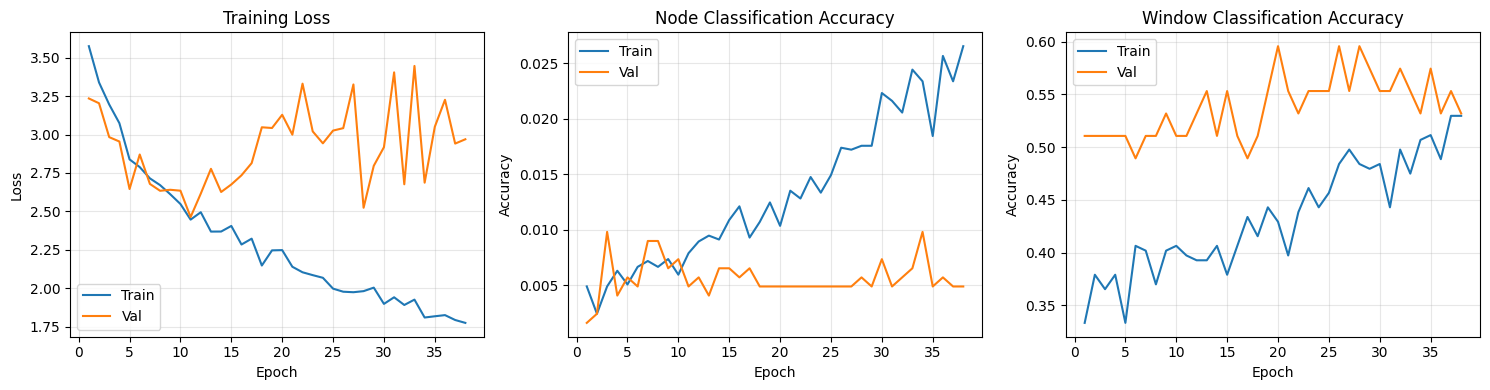

In [78]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = [h["epoch"] for h in history]
# Loss plot
axes[0].plot(epochs, [h["train_loss"] for h in history], label="Train")
axes[0].plot(epochs, [h["val_loss"] for h in history], label="Val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
# Node accuracy
axes[1].plot(epochs, [h["train_node_acc"] for h in history], label="Train")
axes[1].plot(epochs, [h["val_node_acc"] for h in history], label="Val")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Node Classification Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
# Window accuracy
axes[2].plot(epochs, [h["train_window_acc"] for h in history], label="Train")
axes[2].plot(epochs, [h["val_window_acc"] for h in history], label="Val")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy")
axes[2].set_title("Window Classification Accuracy")
axes[2].legend()
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


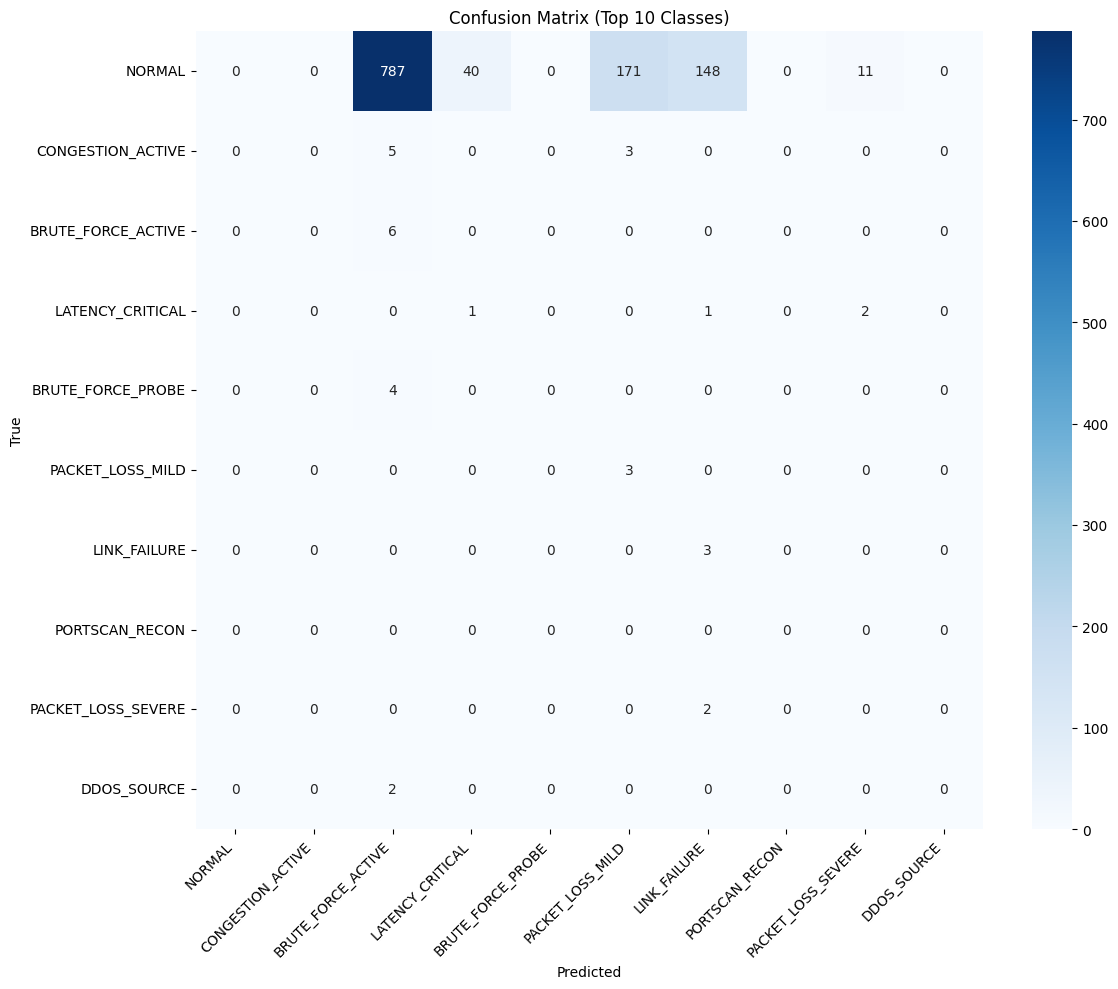

In [79]:
# Confusion Matrix for top classes
from collections import Counter
# Get top 10 most frequent classes
label_counts = Counter(test_metrics["labels"])
top_classes = [label for label, _ in label_counts.most_common(10)]
# Filter for top classes only
mask = np.isin(test_metrics["labels"], top_classes)
filtered_labels = test_metrics["labels"][mask]
filtered_preds = test_metrics["preds"][mask]
cm = confusion_matrix(filtered_labels, filtered_preds, labels=top_classes)
# Plot
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[dataset.index_to_label[i] for i in top_classes],
    yticklabels=[dataset.index_to_label[i] for i in top_classes],
    ax=ax
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (Top 10 Classes)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 6. Inference <a name="inference"></a>

Run inference on specific windows:

In [80]:
@torch.no_grad()
def predict_window(model, dataset, window_idx, device):
    """Predict for a single window."""
    model.eval()
    
    data = dataset[window_idx].to(device)
    data.x = data.x.unsqueeze(0)  # Add batch dim
    
    node_logits, window_logits = model(data)
    
    node_probs = F.softmax(node_logits, dim=-1)
    window_probs = F.softmax(window_logits, dim=-1)
    
    node_preds = node_probs.argmax(dim=-1)
    window_pred = window_probs.argmax(dim=-1).item()
    
    # Top-k predictions
    top_k = 3
    node_top_k = torch.topk(node_probs, k=min(top_k, node_probs.shape[-1]), dim=-1)
    window_top_k = torch.topk(window_probs[0], k=min(top_k, window_probs.shape[-1]))
    
    # Build result
    node_predictions = []
    for i, pred_idx in enumerate(node_preds.cpu().numpy()):
        node_predictions.append({
            "node_idx": i,
            "node_name": dataset.metadata["node_names"][i],
            "predicted_label": dataset.index_to_label[pred_idx],
            "predicted_idx": int(pred_idx),
            "confidence": float(node_probs[i, pred_idx]),
        })
    
    result = {
        "window_idx": window_idx,
        "window_prediction": {
            "label": dataset.index_to_label[window_pred],
            "idx": window_pred,
            "confidence": float(window_probs[0, window_pred]),
            "top_k": [
                {
                    "label": dataset.index_to_label[int(idx)],
                    "prob": float(prob),
                }
                for idx, prob in zip(
                    window_top_k.indices.cpu().numpy(),
                    window_top_k.values.cpu().numpy(),
                )
            ],
        },
        "node_predictions": node_predictions,
        "anomaly_detected": window_pred != 0,
        "affected_nodes": [
            p["node_name"] for p in node_predictions
            if p["predicted_idx"] != 0
        ],
    }
    
    return result
def print_prediction(result):
    """Pretty print prediction."""
    print(f"\n{'='*60}")
    print(f"Prediction for Window {result['window_idx']}")
    print(f"{'='*60}")
    
    win_pred = result["window_prediction"]
    print(f"\nWindow Prediction: {win_pred['label']} (confidence: {win_pred['confidence']:.4f})")
    print("Top-3 predictions:")
    for pred in win_pred["top_k"]:
        print(f"  - {pred['label']}: {pred['prob']:.4f}")
    
    if result["anomaly_detected"]:
        print(f"\nÃ¢ÂÂ Ã¯Â¸Â  ANOMALY DETECTED!")
        print(f"   Affected nodes: {', '.join(result['affected_nodes'])}")
    else:
        print(f"\nÃ¢ÂÂ System Normal")
    
    anomalous = [p for p in result["node_predictions"] if p["predicted_idx"] != 0]
    if anomalous:
        print(f"\nAnomalous nodes:")
        for node in anomalous[:10]:
            print(f"  {node['node_name']}: {node['predicted_label']} (conf: {node['confidence']:.4f})")
    else:
        print(f"\nNo anomalous nodes detected")
    
    print(f"{'='*60}")
# Test inference on a few windows
for idx in [0, 50, 100]:
    if idx < len(dataset):
        result = predict_window(model, dataset, idx, device)
        print_prediction(result)



Prediction for Window 0

Window Prediction: NORMAL (confidence: 0.3031)
Top-3 predictions:
  - NORMAL: 0.3031
  - RECOVERY: 0.1362
  - LATENCY_DEGRADING: 0.1175

Ã¢ÂÂ System Normal

Anomalous nodes:
  dc_monitor: PACKET_LOSS_MILD (conf: 0.3450)
  dc_pub_dns: PACKET_LOSS_MILD (conf: 0.3471)
  dc_vpn: PACKET_LOSS_MILD (conf: 0.3433)
  dc_web: PACKET_LOSS_MILD (conf: 0.3479)
  e1_dhcp: PACKET_LOSS_MILD (conf: 0.3400)
  e1_dns: PACKET_LOSS_MILD (conf: 0.3437)
  e1_erp: PACKET_LOSS_MILD (conf: 0.3457)
  e1_pc1: PACKET_LOSS_MILD (conf: 0.3479)
  e1_pc2: PACKET_LOSS_MILD (conf: 0.3433)
  e2_crm: PACKET_LOSS_MILD (conf: 0.3457)

Prediction for Window 50

Window Prediction: NORMAL (confidence: 0.1748)
Top-3 predictions:
  - NORMAL: 0.1748
  - CONGESTION_ACTIVE: 0.1101
  - RECOVERY: 0.1027

Ã¢ÂÂ System Normal

Anomalous nodes:
  dc_monitor: BRUTE_FORCE_ACTIVE (conf: 0.1255)
  dc_pub_dns: BRUTE_FORCE_ACTIVE (conf: 0.1255)
  dc_vpn: BRUTE_FORCE_ACTIVE (conf: 0.1255)
  dc_web: BRUTE_FORCE_ACTI

# F1 Score by class visualization
fig, ax = plt.subplots(figsize=(14, 6))

# Get unique labels and their F1 scores properly aligned
unique_labels = sorted(set(test_metrics["labels"]))
precision, recall, f1, support = precision_recall_fscore_support(
    test_metrics["labels"], test_metrics["preds"], labels=unique_labels, average=None, zero_division=0
)

x_pos = np.arange(len(unique_labels))
f1_scores = list(f1)  # f1 is already aligned with unique_labels
label_names = [dataset.index_to_label.get(i, f"Class_{i}") for i in unique_labels]

colors = ["green" if f > 0.8 else "orange" if f > 0.5 else "red" for f in f1_scores]
bars = ax.bar(x_pos, f1_scores, color=colors, alpha=0.7)

ax.set_xticks(x_pos)
ax.set_xticklabels(label_names, rotation=45, ha="right")
ax.set_ylabel("F1 Score")
ax.set_title("Per-Class F1 Score on Test Set")
ax.axhline(y=0.8, color="g", linestyle="--", alpha=0.5, label="Good (>0.8)")
ax.axhline(y=0.5, color="r", linestyle="--", alpha=0.5, label="Poor (<0.5)")
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

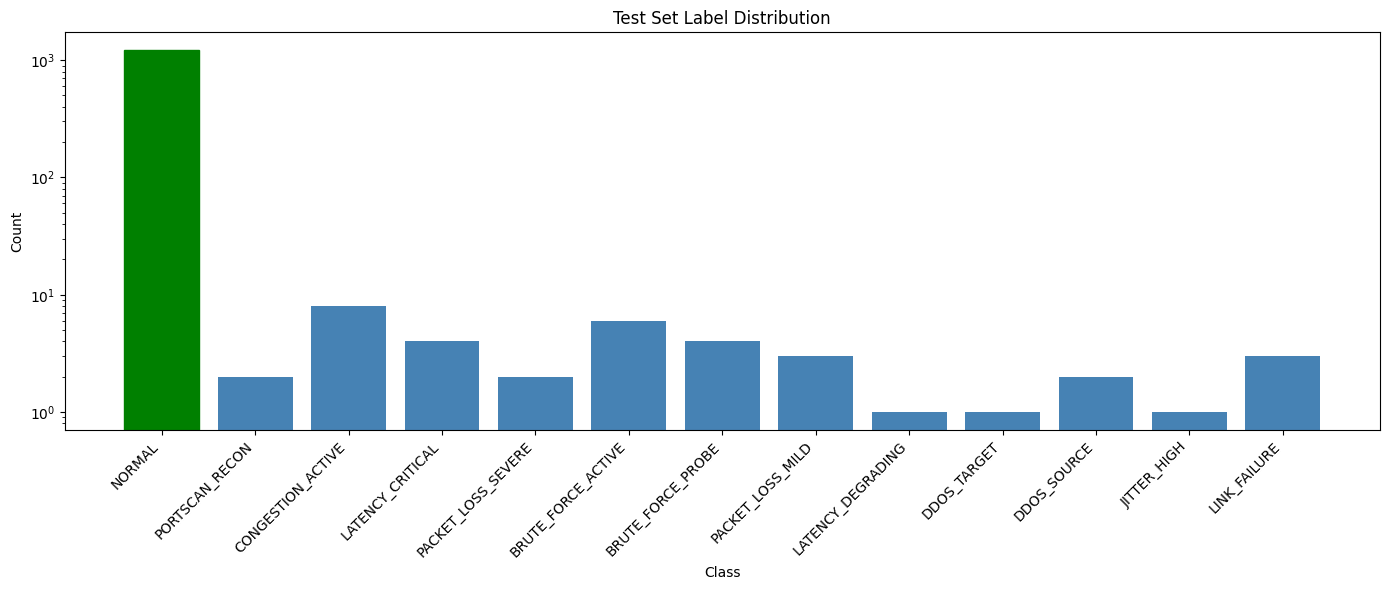


Class imbalance ratio:
  NORMAL: 1:1.0
  PORTSCAN_RECON: 1:605.5
  CONGESTION_ACTIVE: 1:151.4
  LATENCY_CRITICAL: 1:302.8
  PACKET_LOSS_SEVERE: 1:605.5
  BRUTE_FORCE_ACTIVE: 1:201.8
  BRUTE_FORCE_PROBE: 1:302.8
  PACKET_LOSS_MILD: 1:403.7
  LATENCY_DEGRADING: 1:1211.0
  DDOS_TARGET: 1:1211.0
  DDOS_SOURCE: 1:605.5
  JITTER_HIGH: 1:1211.0
  LINK_FAILURE: 1:403.7


In [81]:
# Label distribution visualization
label_counts = Counter(test_metrics["labels"])
labels = [dataset.index_to_label[i] for i in label_counts.keys()]
counts = list(label_counts.values())
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(labels)), counts, color="steelblue")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.set_title("Test Set Label Distribution")
ax.set_yscale("log")
# Highlight NORMAL class
if "NORMAL" in labels:
    normal_idx = labels.index("NORMAL")
    bars[normal_idx].set_color("green")
plt.tight_layout()
plt.show()
print("\nClass imbalance ratio:")
normal_count = label_counts.get(dataset.label_to_index["NORMAL"], 1)
for label, count in zip(labels, counts):
    if count > 0:
        ratio = normal_count / count
        print(f"  {label}: 1:{ratio:.1f}")


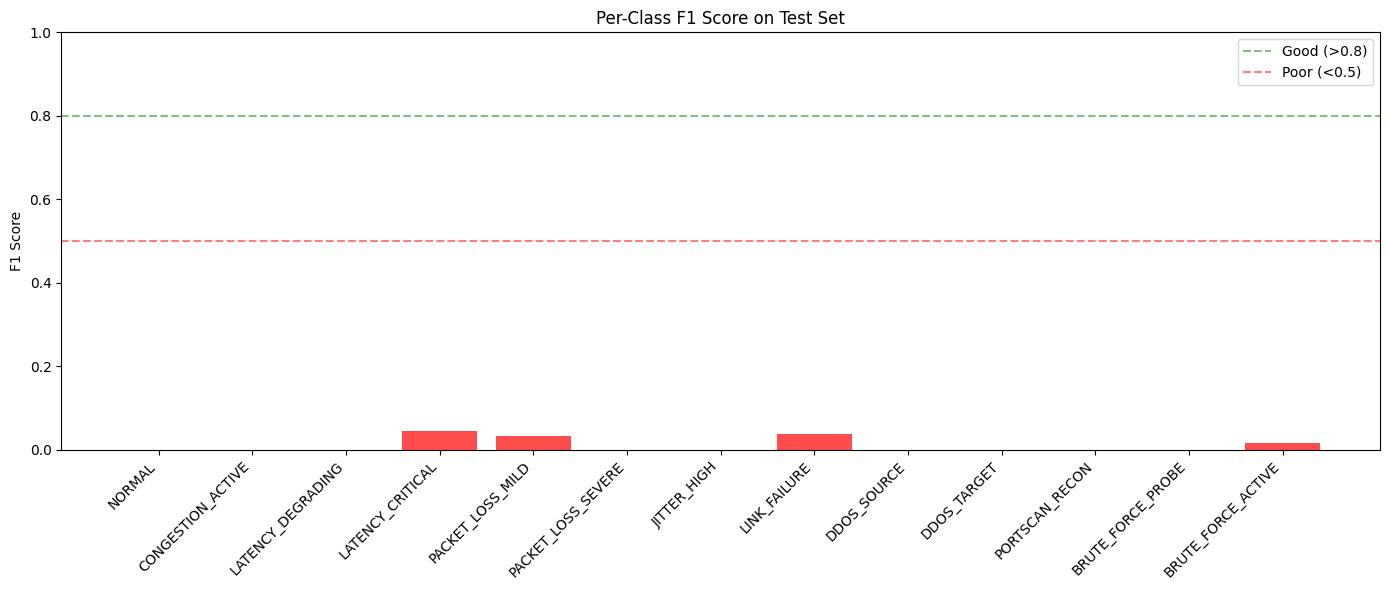

In [82]:
# F1 Score by class visualization
fig, ax = plt.subplots(figsize=(14, 6))
# Get unique labels and their F1 scores properly aligned
unique_labels = sorted(set(test_metrics["labels"]))
precision, recall, f1, support = precision_recall_fscore_support(
    test_metrics["labels"], test_metrics["preds"], labels=unique_labels, average=None, zero_division=0
)
x_pos = np.arange(len(unique_labels))
f1_scores = list(f1)  # f1 is already aligned with unique_labels positions
label_names = [dataset.index_to_label.get(i, f"Class_{i}") for i in unique_labels]
colors = ["green" if f > 0.8 else "orange" if f > 0.5 else "red" for f in f1_scores]
bars = ax.bar(x_pos, f1_scores, color=colors, alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels(label_names, rotation=45, ha="right")
ax.set_ylabel("F1 Score")
ax.set_title("Per-Class F1 Score on Test Set")
ax.axhline(y=0.8, color="g", linestyle="--", alpha=0.5, label="Good (>0.8)")
ax.axhline(y=0.5, color="r", linestyle="--", alpha=0.5, label="Poor (<0.5)")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


In [83]:
# Save model and results
import pickle
# Save model
torch.save({
    "model_state_dict": model.state_dict(),
    "config": CONFIG,
    "history": history,
    "test_metrics": {
        "loss": test_metrics["loss"],
        "node_acc": test_metrics["node_acc"],
        "window_acc": test_metrics["window_acc"],
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    },
}, "gnn_model_complete.pt")
# Save label mapping
with open("label_mapping.json", "w") as f:
    json.dump({
        "label_to_index": dataset.label_to_index,
        "index_to_label": dataset.index_to_label,
        "node_names": dataset.metadata["node_names"],
    }, f, indent=2)
print("Ã¢ÂÂ Model saved to: gnn_model_complete.pt")
print("Ã¢ÂÂ Label mapping saved to: label_mapping.json")
# Summary
print(f"\n{'='*60}")
print(f"Training Summary")
print(f"{'='*60}")
print(f"Model: TemporalGAT")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Epochs trained: {len(history)}")
print(f"\nBest validation loss: {best_val_loss:.4f}")
print(f"Test node accuracy: {test_metrics['node_acc']:.4f}")
print(f"Test window accuracy: {test_metrics['window_acc']:.4f}")
print(f"Test macro F1: {macro_f1:.4f}")
print(f"{'='*60}")


Ã¢ÂÂ Model saved to: gnn_model_complete.pt
Ã¢ÂÂ Label mapping saved to: label_mapping.json

Training Summary
Model: TemporalGAT
Parameters: 216,106
Epochs trained: 38

Best validation loss: 2.6338
Test node accuracy: 0.0104
Test window accuracy: 0.5417
Test macro F1: 0.0100
